#### **Monte Carlo every-visit on Volcano World**

In this example we apply MC every-visit to the custom `VolcanoWorldEnv`.

Terminal rules used here:
- `L` lava: reward `-50`, terminal
- `G` safe: reward `+2`, terminal
- `V` view: reward `+20`, terminal

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

from volcano_rl import VolcanoWorldEnv

try:
    import session_info
except ImportError:
    session_info = None

In [3]:
n_episodes = 200000
current_epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.1
Reward_list = []


# Hyperparameters
n_episodes = 2000000
max_steps = 30
gamma = 0.99  # Discount factor
alpha = 0.01  # Learning rate
epsilon_max = 1.0
epsilon_min = 0.1


In [4]:
def print_policy(Q, env, cols, rows):
    def action_to_symbol(action):
        return ['↑', '→', '↓', '←'][action]

    policy = np.zeros((rows, cols), dtype=str)
    for state in range(env.observation_space.n):
        if np.sum(Q[state]) == 0:
            policy[state // cols, state % cols] = 'o'
        else:
            best_action = np.argmax(Q[state])
            policy[state // cols, state % cols] = action_to_symbol(best_action)

    desc = env.desc
    for i in range(rows):
        for j in range(cols):
            if desc[i][j] in ['L', 'V', 'G']:
                policy[i, j] = desc[i][j]
    policy[1, 0] = 'S'

    print('=== Learned Policy ===')
    print()
    for row in policy:
        print(' '.join(row))

In [5]:
# Initialize the environment
env = VolcanoWorldEnv(is_slippery=False, slip_probabilities=(1 / 3, 1 / 3, 1 / 3))

# Initialize Q-table
Q = np.zeros((env.observation_space.n, env.action_space.n))
N = np.zeros((env.observation_space.n, env.action_space.n))  # For tracking visit counts

print(Q.shape)

def epsilon_greedy_policy(state, epsilon):  # Exploitation vs Exploration
    if np.random.random() < epsilon:
        return random.randrange(env.action_space.n)
    else:
        return np.argmax(Q[state])

total_rewards = []

for episode in range(n_episodes):
    state, _ = env.reset()
    epsilon = max(epsilon_min, epsilon_max - (epsilon_max - epsilon_min) * (episode / n_episodes))

    episode_states = []
    episode_actions = []
    episode_rewards = []

    for step in range(max_steps):
        action = epsilon_greedy_policy(state, epsilon)

        next_state, reward, done, _, _ = env.step(action)

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)

        if done:
            break

        state = next_state

    # Calculate returns and update Q-table
    G = 0
    for t in range(len(episode_states) - 1, -1, -1):
        state = episode_states[t]
        action = episode_actions[t]
        G = gamma * G + episode_rewards[t]

        N[state, action] += 1
        Q[state, action] += alpha * (G - Q[state, action])

    total_rewards.append(sum(episode_rewards))

    if (episode + 1) % 1000 == 0:
        avg_reward = np.mean(total_rewards[-1000:])
        print(f'Episode: {episode + 1}, Average Reward (last 1000 episodes): {avg_reward:.2f}')

print('Training completed.')

(12, 4)
Episode: 1000, Average Reward (last 1000 episodes): -18.70
Episode: 2000, Average Reward (last 1000 episodes): -19.31
Episode: 3000, Average Reward (last 1000 episodes): -21.17
Episode: 4000, Average Reward (last 1000 episodes): -19.46
Episode: 5000, Average Reward (last 1000 episodes): -17.14
Episode: 6000, Average Reward (last 1000 episodes): -19.36
Episode: 7000, Average Reward (last 1000 episodes): -18.72
Episode: 8000, Average Reward (last 1000 episodes): -17.68
Episode: 9000, Average Reward (last 1000 episodes): -18.25
Episode: 10000, Average Reward (last 1000 episodes): -19.83
Episode: 11000, Average Reward (last 1000 episodes): -17.45
Episode: 12000, Average Reward (last 1000 episodes): -20.00
Episode: 13000, Average Reward (last 1000 episodes): -17.38
Episode: 14000, Average Reward (last 1000 episodes): -19.05
Episode: 15000, Average Reward (last 1000 episodes): -20.65
Episode: 16000, Average Reward (last 1000 episodes): -17.66
Episode: 17000, Average Reward (last 1000

In [6]:
# Test the learned policy
n_test_episodes = 100
test_rewards = []

for _ in range(n_test_episodes):
    state = env.reset()[0]
    episode_reward = 0

    for _ in range(max_steps):
        action = np.argmax(Q[state])
        next_state, reward, done, _, _ = env.step(action)
        episode_reward += reward
        if done:
            break
        state = next_state

    test_rewards.append(episode_reward)

print(f'Average reward over {n_test_episodes} test episodes: {np.mean(test_rewards):.2f}')

Average reward over 100 test episodes: 20.00


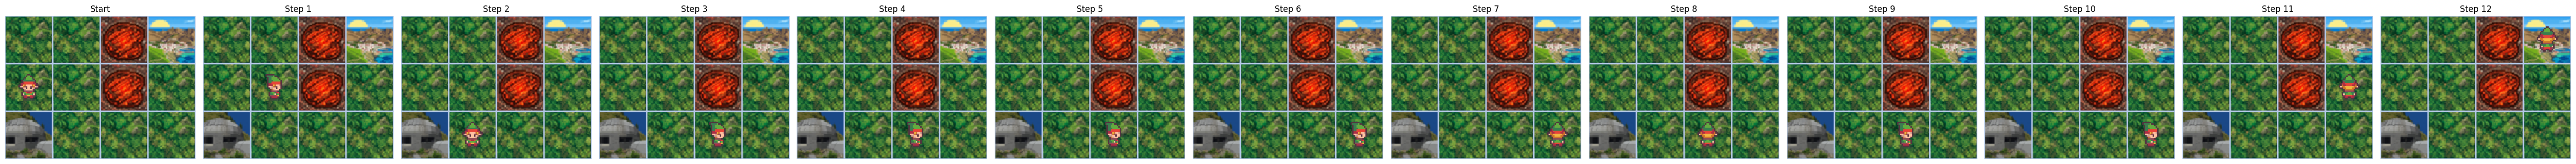

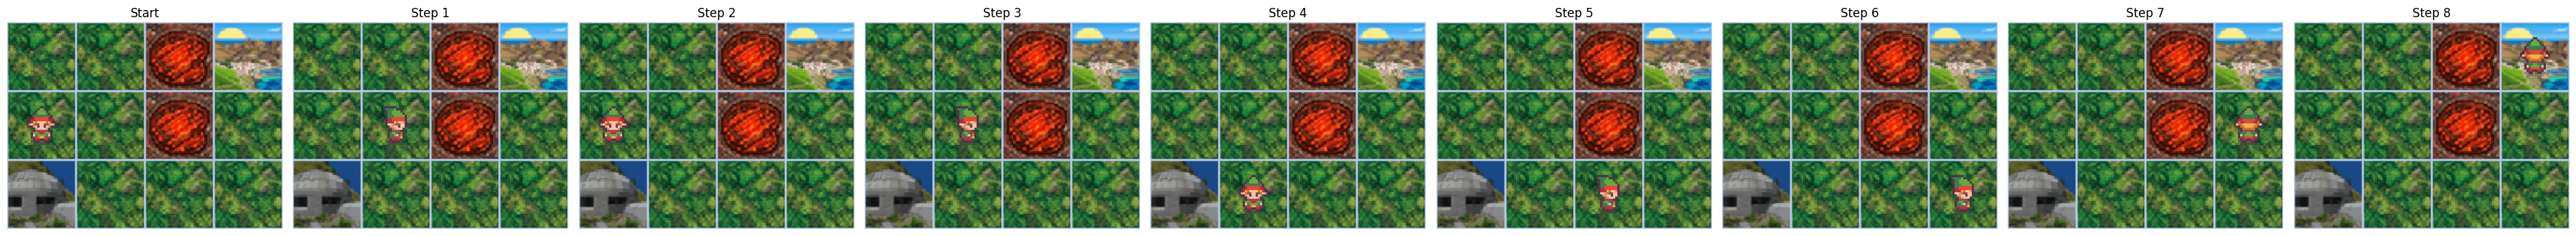

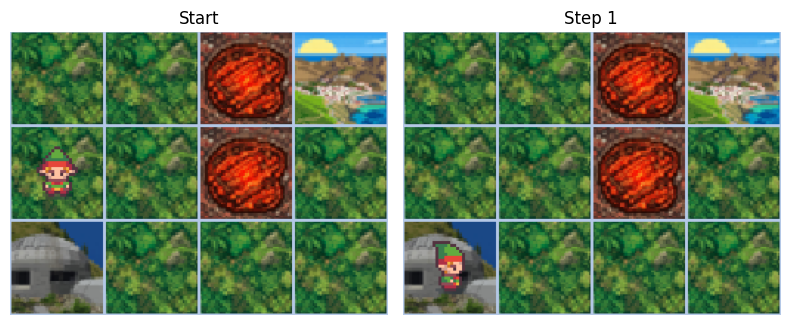

Average reward over 3 demo episodes: 14.00


In [7]:
# Simulate episodes with the learned policy using rgb_array for inline notebook visualization
demo_env = VolcanoWorldEnv(render_mode='rgb_array', is_slippery=True, slip_probabilities=(1 / 3, 1 / 3, 1 / 3))
n_test_episodes = 3
test_rewards = []

for episode in range(n_test_episodes):
    state = demo_env.reset()[0]
    episode_reward = 0
    frames = [('Start', demo_env.render())]

    for step in range(max_steps):
        action = np.argmax(Q[state])
        next_state, reward, done, _, _ = demo_env.step(action)
        frames.append((f'Step {step + 1}', demo_env.render()))
        episode_reward += reward
        if done:
            break
        state = next_state

    test_rewards.append(episode_reward)

    fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 4))
    if len(frames) == 1:
        axes = [axes]
    for ax, (title, frame) in zip(axes, frames):
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print(f'Average reward over {n_test_episodes} demo episodes: {np.mean(test_rewards):.2f}')
demo_env.close()

In [8]:
print_policy(Q, env, 4, 3)

=== Learned Policy ===

↓ ↓ L V
S ↓ L ↑
G → → ↑


In [9]:
# Optional: open the live pygame window instead of plotting frames inline
# Do not use matplotlib with render_mode='human', because human render returns None.

human_env = VolcanoWorldEnv(render_mode='human', is_slippery=False, slip_probabilities=(1 / 3, 1 / 3, 1 / 3))
n_test_episodes = 3
test_rewards = []

for episode in range(n_test_episodes):
    state = human_env.reset()[0]
    episode_reward = 0

    for step in range(max_steps):
        action = np.argmax(Q[state])
        next_state, reward, done, _, _ = human_env.step(action)
        episode_reward += reward
        if done:
            break
        state = next_state

    test_rewards.append(episode_reward)

print(f'Average reward over {n_test_episodes} human-render episodes: {np.mean(test_rewards):.2f}')
human_env.close()

Average reward over 3 human-render episodes: 20.00


In [10]:
import pygame


In [11]:
# Optional: open the live pygame window and record it to output.avi
# Requires both pygame and opencv-python in the notebook kernel.

import pygame
import cv2
import numpy as np

human_env = VolcanoWorldEnv(render_mode='human', is_slippery=False, slip_probabilities=(1 / 3, 1 / 3, 1 / 3))
n_test_episodes = 3
test_rewards = []

width, height = human_env.window_size
video_fps = 5
frame_repeat = 6
out = cv2.VideoWriter('output.avi', cv2.VideoWriter_fourcc(*'XVID'), video_fps, (width, height))

def capture_frame(env, writer, repeat=1):
    screen = env._human_window
    frame = pygame.surfarray.array3d(screen)
    frame = frame.transpose([1, 0, 2])
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    for _ in range(repeat):
        writer.write(frame)

for episode in range(n_test_episodes):
    state = human_env.reset()[0]
    episode_reward = 0
    capture_frame(human_env, out, frame_repeat)

    for step in range(max_steps):
        action = np.argmax(Q[state])
        next_state, reward, done, _, _ = human_env.step(action)
        capture_frame(human_env, out, frame_repeat)
        episode_reward += reward
        if done:
            break
        state = next_state

    test_rewards.append(episode_reward)

out.release()
human_env.close()
print(f'Average reward over {n_test_episodes} human-render episodes: {np.mean(test_rewards):.2f}')
print('Saved video to output.avi')

Average reward over 3 human-render episodes: 20.00
Saved video to output.avi
